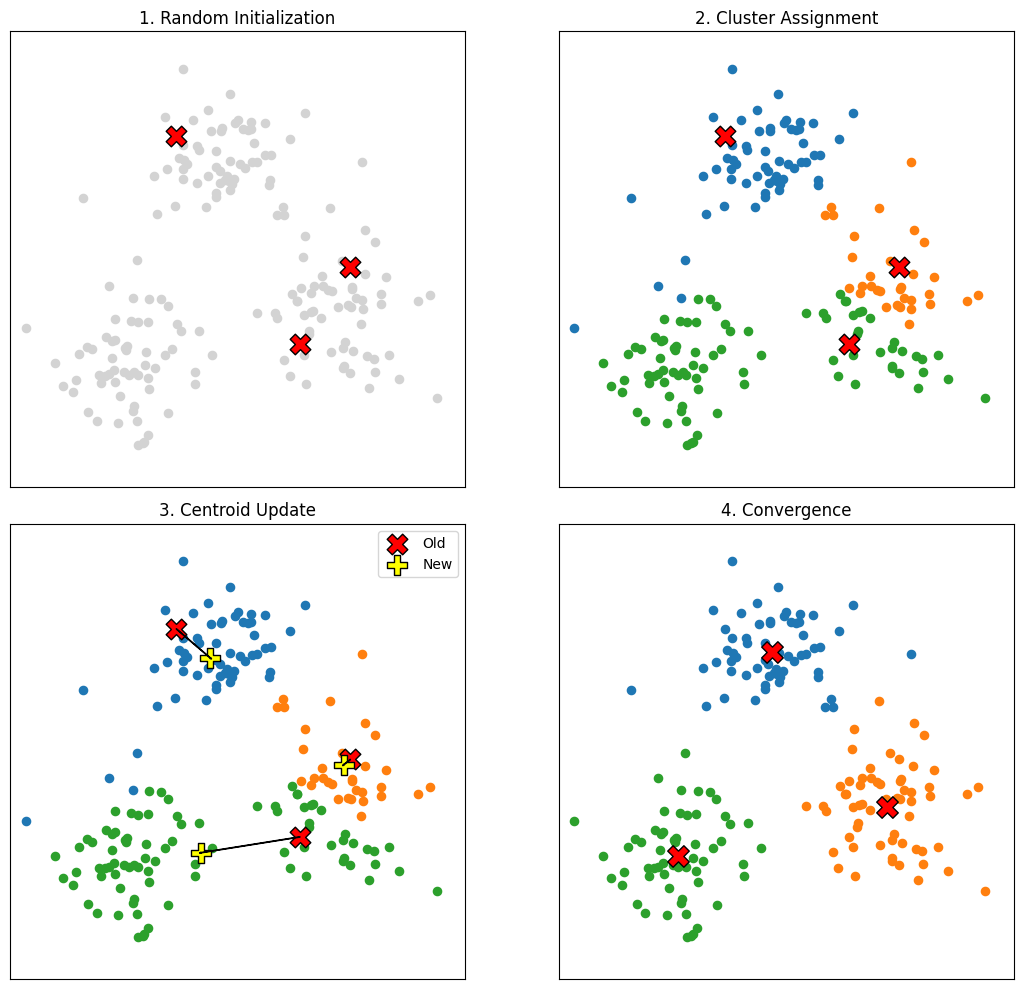

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Generate sample data
# =========================
np.random.seed(42)

cluster1 = np.random.randn(60, 2) + np.array([1, 1])
cluster2 = np.random.randn(60, 2) + np.array([6, 2])
cluster3 = np.random.randn(60, 2) + np.array([3, 6])

X = np.vstack((cluster1, cluster2, cluster3))

k = 3

# =========================
# Step 1: Random Initialization
# =========================
random_idx = np.random.choice(len(X), k, replace=False)
centroids0 = X[random_idx]

# =========================
# Step 2: Cluster Assignment
# =========================
dist = np.linalg.norm(X[:, None] - centroids0, axis=2)
labels1 = np.argmin(dist, axis=1)

# =========================
# Step 3: Centroid Update
# =========================
centroids1 = np.array([X[labels1 == i].mean(axis=0) for i in range(k)])

# =========================
# Continue until convergence
# =========================
centroids = centroids1.copy()

while True:
    dist = np.linalg.norm(X[:, None] - centroids, axis=2)
    labels = np.argmin(dist, axis=1)

    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

    if np.allclose(new_centroids, centroids):
        break

    centroids = new_centroids

final_centroids = centroids
final_labels = labels

# =========================
# Visualization
# =========================
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)

# -------------------------
# 1. Random Initialization
# -------------------------
ax = axes[0, 0]

ax.scatter(X[:, 0], X[:, 1], c="lightgray", s=35)

ax.scatter(
    centroids0[:, 0], centroids0[:, 1], marker="X", s=220, c="red", edgecolor="black"
)

ax.set_title("1. Random Initialization")

# -------------------------
# 2. Cluster Assignment
# -------------------------
ax = axes[0, 1]

for i in range(k):
    ax.scatter(X[labels1 == i, 0], X[labels1 == i, 1], s=35, color=colors[i])

ax.scatter(
    centroids0[:, 0], centroids0[:, 1], marker="X", s=220, c="red", edgecolor="black"
)

ax.set_title("2. Cluster Assignment")

# -------------------------
# 3. Centroid Update
# -------------------------
ax = axes[1, 0]

for i in range(k):
    ax.scatter(X[labels1 == i, 0], X[labels1 == i, 1], s=35, color=colors[i])

# old centroids
ax.scatter(
    centroids0[:, 0],
    centroids0[:, 1],
    marker="X",
    s=220,
    c="red",
    edgecolor="black",
    label="Old",
)

# new centroids
ax.scatter(
    centroids1[:, 0],
    centroids1[:, 1],
    marker="P",
    s=220,
    c="yellow",
    label="New",
    edgecolor="black",
)

# arrows
for i in range(k):
    ax.arrow(
        centroids0[i, 0],
        centroids0[i, 1],
        centroids1[i, 0] - centroids0[i, 0],
        centroids1[i, 1] - centroids0[i, 1],
        width=0.01,
        head_width=0.03,
        color="black",
    )

ax.legend()
ax.set_title("3. Centroid Update")

# -------------------------
# 4. Convergence
# -------------------------
ax = axes[1, 1]

for i in range(k):
    ax.scatter(X[final_labels == i, 0], X[final_labels == i, 1], s=35, color=colors[i])

ax.scatter(
    final_centroids[:, 0],
    final_centroids[:, 1],
    marker="X",
    s=240,
    c="red",
    edgecolor="black",
)

ax.set_title("4. Convergence")

# =========================
# Beautify
# =========================
for ax in axes.flat:
    ax.set_xlim(-2, 9)
    ax.set_ylim(-2, 9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

plt.tight_layout(w_pad=0)
# plt.show()
plt.savefig("kmeans.png", dpi=600, bbox_inches="tight")